# Tellus Geochemical EDA - Plot-first notebook

This notebook focuses on visual exploratory analysis for the Ireland and Northern Ireland Tellus geochemical data.

It avoids exporting summary spreadsheets. The goal is to quickly see:

- what data is available by region and sample medium
- where samples are located
- which analytes are missing or well populated
- how selected elements are distributed
- how shallow/deeper soils, stream sediments, and waters differ
- which analytes move together through correlations

Northern Ireland source files are legacy `.xls`; install `xlrd` or convert them to `.xlsx` if the loader reports they were skipped.

## 0. Setup

Run the install cell only if the dependency check says packages are missing.

In [ ]:
# Optional: uncomment if your notebook environment is missing plotting or Excel readers.
# import sys, subprocess
# subprocess.check_call([
#     sys.executable, "-m", "pip", "install",
#     "pandas", "numpy", "openpyxl", "xlrd", "matplotlib", "seaborn", "scikit-learn"
# ])

In [2]:
from pathlib import Path
import importlib.util
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 40)

required = ["pandas", "numpy", "openpyxl"]
optional = ["xlrd", "matplotlib", "seaborn", "sklearn"]
package_status = {pkg: importlib.util.find_spec(pkg) is not None for pkg in required + optional}
package_status

{'pandas': True,
 'numpy': True,
 'openpyxl': True,
 'xlrd': True,
 'matplotlib': True,
 'seaborn': True,
 'sklearn': True}

## 1. Find and load geochemical workbooks

In [3]:
ROOT = Path.cwd()
IRELAND_GEOCHEM = ROOT / "Ireland" / "1. Geochem"
NI_GEOCHEM = ROOT / "Northern Ireland" / "2. Geochem"

print("Ireland folder:", IRELAND_GEOCHEM)
print("Northern Ireland folder:", NI_GEOCHEM)

Ireland folder: c:\2. Tellus Programme\2. Tellus Programme\Ireland\1. Geochem
Northern Ireland folder: c:\2. Tellus Programme\2. Tellus Programme\Northern Ireland\2. Geochem


In [4]:
def inventory_files():
    rows = []
    for region, base in [("Ireland", IRELAND_GEOCHEM), ("Northern Ireland", NI_GEOCHEM)]:
        if not base.exists():
            continue
        for path in list(base.rglob("*.xlsx")) + list(base.rglob("*.xls")):
            rows.append({
                "region": region,
                "path": path,
                "source_file": path.relative_to(ROOT).as_posix(),
                "extension": path.suffix.lower(),
                "size_mb": path.stat().st_size / 1024**2,
            })
    return pd.DataFrame(rows).sort_values(["region", "source_file"]).reset_index(drop=True)

inventory = inventory_files()
print(f"Workbook count: {len(inventory)}")
inventory[["region", "source_file", "extension", "size_mb"]]

Workbook count: 17


,region,source_file,extension,size_mb
0,Ireland,Ireland/1. Geochem/1. C_Stream_sediment_geoche...,.xlsx,2.890136
1,Ireland,Ireland/1. Geochem/2. W_Stream_water_geochemis...,.xlsx,3.208023
2,Ireland,Ireland/1. Geochem/3. Lithium_Stream Sediments...,.xlsx,0.112416
3,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,.xlsx,3.900958
4,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,.xlsx,2.016800
5,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,.xlsx,1.362432
6,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,.xlsx,0.438540
7,Ireland,Ireland/1. Geochem/5. Deeper_Topsoil_S/Excel/G...,.xlsx,5.050673
8,Ireland,Ireland/1. Geochem/5. Deeper_Topsoil_S/Excel/G...,.xlsx,2.022526
9,Ireland,Ireland/1. Geochem/5. Deeper_Topsoil_S/Excel/G...,.xlsx,0.434569


In [5]:
def normalise_name(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name).strip()).strip("_")

SHEET_EXCLUDE = {
    "read_me", "readme", "units_detection_limits", "data_below_lld",
    "conditioned_ph_data", "metadata"
}

def is_likely_data_sheet(sheet_name):
    key = normalise_name(sheet_name).lower()
    return key not in SHEET_EXCLUDE and not key.startswith("unit") and not key.startswith("read")

def infer_dataset_kind(path):
    text = path.as_posix().lower()
    if "stream_sediment" in text or "sediment" in text:
        return "stream sediment"
    if "stream_water" in text or "water" in text:
        return "stream water"
    if "lithium" in text or "li_aas" in text:
        return "lithium stream sediment"
    if "shallow_topsoil" in text or "soils_a" in text or "_a_" in text:
        return "shallow topsoil A"
    if "deeper_topsoil" in text or "soils_s" in text or "_s_" in text:
        return "deeper topsoil S"
    return "other geochem"

def read_workbook(path, region, max_rows=None):
    path = Path(path)
    if path.suffix.lower() == ".xlsx":
        engine = "openpyxl"
    elif path.suffix.lower() == ".xls":
        engine = "xlrd"
        if not package_status.get("xlrd", False):
            raise ImportError("Reading .xls files requires xlrd. Install xlrd or convert this workbook to .xlsx/.csv.")
    else:
        raise ValueError(f"Unsupported workbook type: {path.suffix}")

    xls = pd.ExcelFile(path, engine=engine)
    frames = []
    for sheet in xls.sheet_names:
        if not is_likely_data_sheet(sheet):
            continue
        df = pd.read_excel(path, sheet_name=sheet, engine=engine, nrows=max_rows)
        df = df.dropna(how="all")
        if df.empty:
            continue
        df.columns = [normalise_name(c) for c in df.columns]
        meta = pd.DataFrame({
            "dataset": path.stem,
            "sheet": sheet,
            "region": region,
            "sample_media": infer_dataset_kind(path),
            "source_file": path.relative_to(ROOT).as_posix(),
        }, index=df.index)
        frames.append(pd.concat([meta, df], axis=1).copy())
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

def load_geochem(max_rows=None):
    datasets = []
    log_rows = []
    for _, row in inventory.iterrows():
        try:
            df = read_workbook(row["path"], row["region"], max_rows=max_rows)
            datasets.append(df)
            log_rows.append({"region": row["region"], "source_file": row["source_file"], "status": "loaded", "rows": len(df)})
        except Exception as exc:
            log_rows.append({"region": row["region"], "source_file": row["source_file"], "status": "skipped", "rows": 0, "reason": str(exc)})
    geo = pd.concat(datasets, ignore_index=True, sort=False) if datasets else pd.DataFrame()
    return geo, pd.DataFrame(log_rows)

# Set max_rows=1000 while developing. Use None for full plotting.
geo, load_log = load_geochem(max_rows=None)
print("Combined data shape:", geo.shape)
load_log

Combined data shape: (105506, 339)


,region,source_file,status,rows
0,Ireland,Ireland/1. Geochem/1. C_Stream_sediment_geoche...,loaded,8861
1,Ireland,Ireland/1. Geochem/2. W_Stream_water_geochemis...,loaded,6836
2,Ireland,Ireland/1. Geochem/3. Lithium_Stream Sediments...,loaded,1906
3,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,loaded,5643
4,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,loaded,4278
5,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,loaded,2820
6,Ireland,Ireland/1. Geochem/4. Shallow_Topsoil_A/Excel/...,loaded,877
7,Ireland,Ireland/1. Geochem/5. Deeper_Topsoil_S/Excel/G...,loaded,5642
8,Ireland,Ireland/1. Geochem/5. Deeper_Topsoil_S/Excel/G...,loaded,4278
9,Ireland,Ireland/1. Geochem/5. Deeper_Topsoil_S/Excel/G...,loaded,877


## 2. Detect numeric columns, IDs, coordinates, and analyte names

In [6]:
META_COLUMNS = {"dataset", "sheet", "region", "sample_media", "source_file"}
ID_PATTERNS = [r"sample.*id", r"gsi.*id", r"lab.*no"]
COORD_PATTERNS = [r"east", r"north", r"x_itm", r"y_itm", r"x_ing", r"y_ing", r"latitude", r"longitude"]

def columns_matching(df, patterns):
    out = []
    for col in df.columns:
        key = col.lower()
        if any(re.search(pattern, key) for pattern in patterns):
            out.append(col)
    return out

def likely_numeric_columns(df, min_numeric_fraction=0.60):
    id_cols = set(columns_matching(df, ID_PATTERNS))
    cols = []
    for col in df.columns:
        if col in META_COLUMNS or col in id_cols:
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        denom = df[col].notna().sum()
        if denom and (s.notna().sum() / denom) >= min_numeric_fraction:
            cols.append(col)
    return cols

def make_numeric(df):
    df = df.copy()
    cols = likely_numeric_columns(df)
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, cols

def analyte_key(col):
    c = str(col)
    c = re.sub(r"_(mgkg|mgL|ugL|ppm|ppb|perc|percent|pct).*$", "", c, flags=re.IGNORECASE)
    c = re.sub(r"_%.*$", "", c)
    c = re.sub(r"_(XRFS|ICPar|ICP|AAS|HDL|BLD|MS41L).*$", "", c, flags=re.IGNORECASE)
    return c.strip("_")

geo_num, numeric_cols = make_numeric(geo)
id_cols = columns_matching(geo_num, ID_PATTERNS)
coord_cols = columns_matching(geo_num, COORD_PATTERNS)
analyte_map = pd.DataFrame({"column": numeric_cols})
analyte_map["analyte"] = analyte_map["column"].map(analyte_key)

print(f"Rows: {len(geo_num):,}")
print(f"Numeric/analyte-like columns: {len(numeric_cols):,}")
print("ID columns:", id_cols)
print("Coordinate columns:", coord_cols)

Rows: 105,506
Numeric/analyte-like columns: 326
ID columns: ['Sample_ID', 'GSI_ID', 'LABNO', 'Sample_Ide']
Coordinate columns: ['Easting_ING', 'Northing_ING', 'X_ING', 'Y_ING', 'X_ITM', 'Y_ITM', 'Easting_ITM', 'Northing_ITM', 'EASTING', 'NORTHING', 'Easting', 'Northing']


In [7]:
def build_long_table(max_columns=None):
    cols = numeric_cols if max_columns is None else numeric_cols[:max_columns]
    base = [c for c in ["region", "sample_media", "dataset", "source_file"] if c in geo_num.columns]
    parts = []
    for col in cols:
        temp = geo_num[base + [col]].rename(columns={col: "value"}).copy()
        temp["column"] = col
        temp["analyte"] = analyte_key(col)
        temp = temp.dropna(subset=["value"])
        parts.append(temp)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

long_geo = build_long_table()
print("Long plotting table:", long_geo.shape)

Long plotting table: (5101091, 7)


## 3. Data coverage plots

In [9]:
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception as exc:
    HAS_MPL = False
    print("Matplotlib is needed for the plot cells. Run the install cell above, then restart the kernel.")
    print(exc)

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    HAS_SEABORN = False

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False

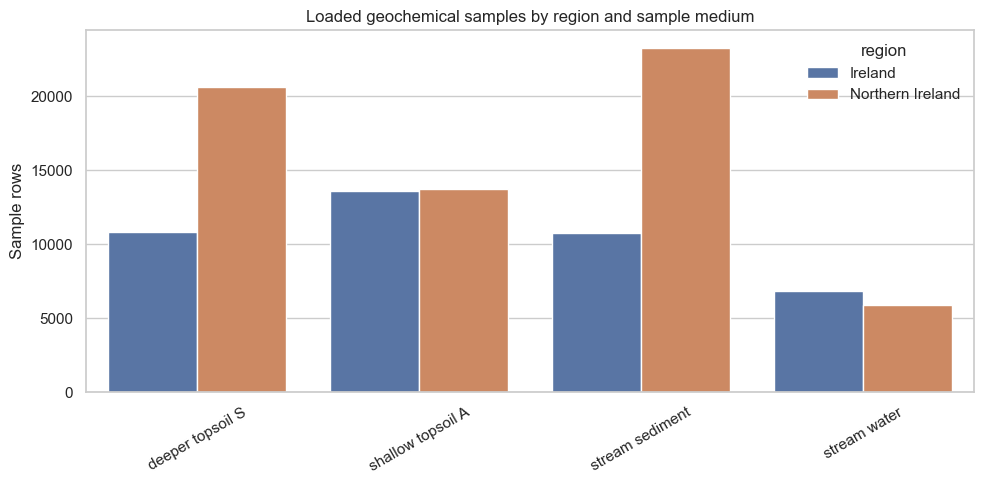

In [10]:
coverage = (
    geo_num.groupby(["region", "sample_media", "dataset"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = coverage.groupby(["region", "sample_media"], dropna=False)["rows"].sum().reset_index()
    if HAS_SEABORN:
        sns.barplot(data=plot_df, x="sample_media", y="rows", hue="region", ax=ax)
    else:
        plot_df.pivot(index="sample_media", columns="region", values="rows").plot(kind="bar", ax=ax)
    ax.set_title("Loaded geochemical samples by region and sample medium")
    ax.set_xlabel("")
    ax.set_ylabel("Sample rows")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
else:
    print("Install matplotlib to view this plot.")

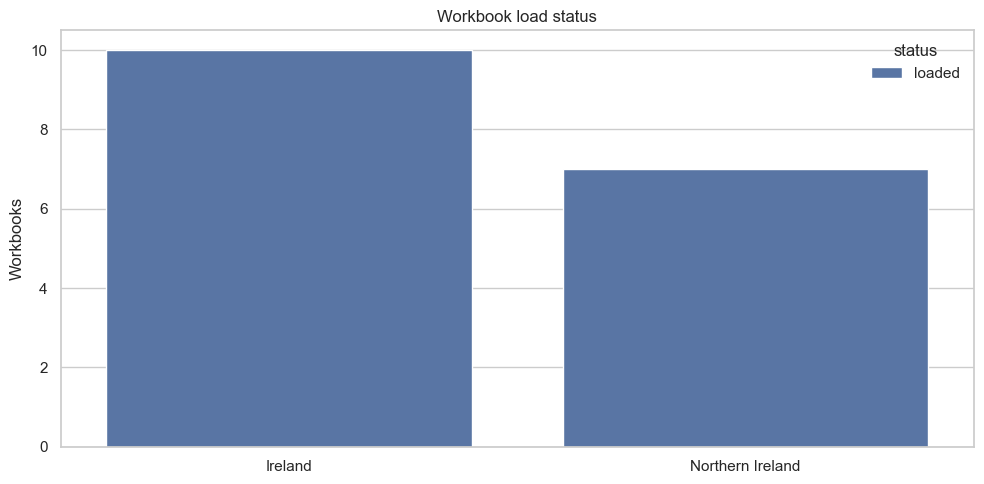

In [11]:
if HAS_MPL:
    fig, ax = plt.subplots(figsize=(10, 5))
    status_df = load_log.groupby(["region", "status"]).size().reset_index(name="workbooks")
    if HAS_SEABORN:
        sns.barplot(data=status_df, x="region", y="workbooks", hue="status", ax=ax)
    else:
        status_df.pivot(index="region", columns="status", values="workbooks").plot(kind="bar", ax=ax)
    ax.set_title("Workbook load status")
    ax.set_xlabel("")
    ax.set_ylabel("Workbooks")
    plt.tight_layout()
else:
    print("Install matplotlib to view this plot.")

## 4. Missingness and data density

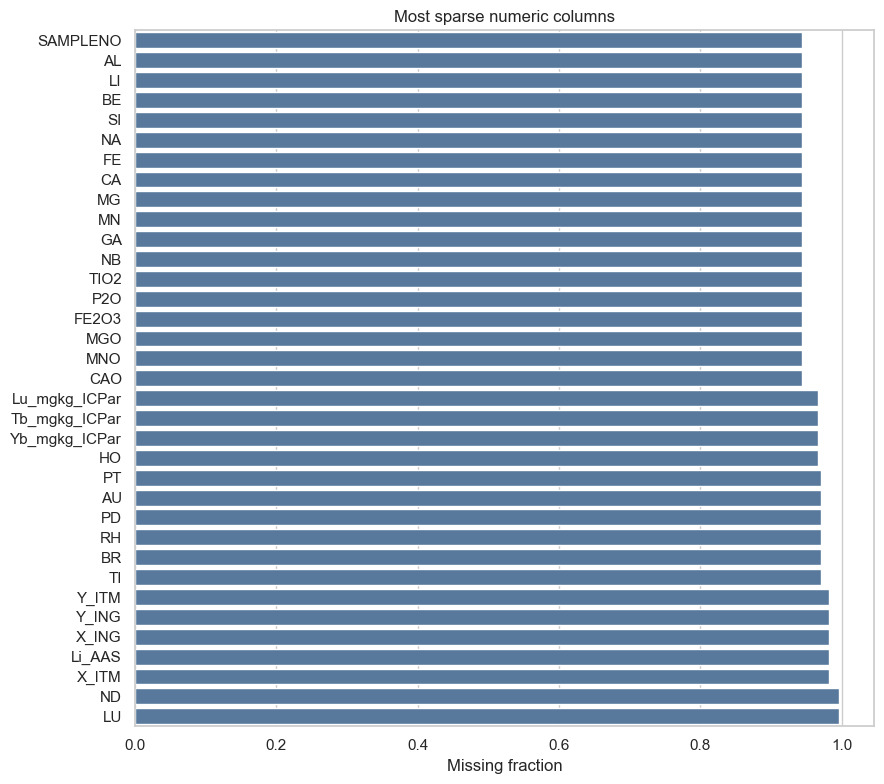

In [12]:
missing = geo_num[numeric_cols].isna().mean().sort_values(ascending=False)
plot_missing = missing.head(35).reset_index()
plot_missing.columns = ["column", "missing_fraction"]

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(9, 8))
    if HAS_SEABORN:
        sns.barplot(data=plot_missing, y="column", x="missing_fraction", color="#4C78A8", ax=ax)
    else:
        ax.barh(plot_missing["column"], plot_missing["missing_fraction"])
    ax.set_title("Most sparse numeric columns")
    ax.set_xlabel("Missing fraction")
    ax.set_ylabel("")
    ax.invert_yaxis()
    plt.tight_layout()
else:
    print("Install matplotlib to view this plot.")

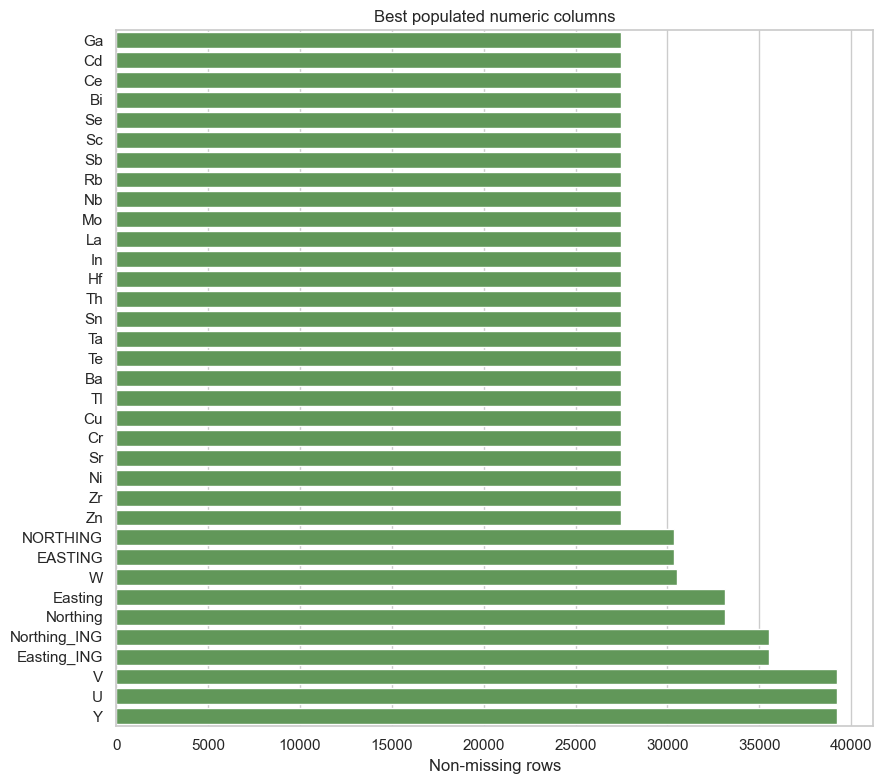

In [13]:
non_missing = geo_num[numeric_cols].notna().sum().sort_values(ascending=False).head(35).reset_index()
non_missing.columns = ["column", "non_missing_rows"]

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(9, 8))
    if HAS_SEABORN:
        sns.barplot(data=non_missing, y="column", x="non_missing_rows", color="#59A14F", ax=ax)
    else:
        ax.barh(non_missing["column"], non_missing["non_missing_rows"])
    ax.set_title("Best populated numeric columns")
    ax.set_xlabel("Non-missing rows")
    ax.set_ylabel("")
    ax.invert_yaxis()
    plt.tight_layout()
else:
    print("Install matplotlib to view this plot.")

## 5. Spatial plots

These use whichever coordinate columns are detected first. Confirm coordinate reference systems before making formal spatial interpretations.

Using coordinate columns: Easting_ITM Northing_ITM


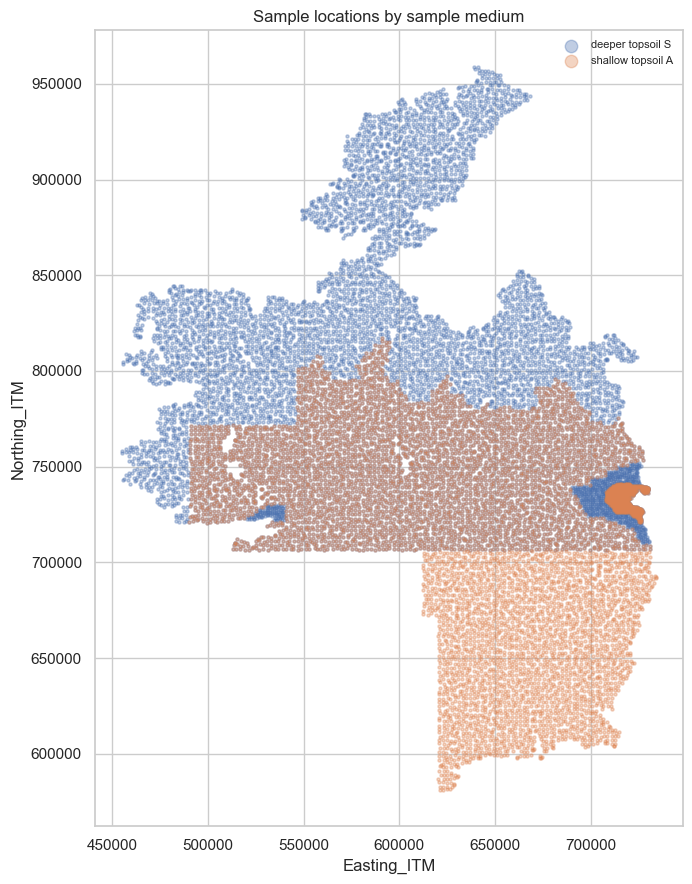

In [14]:
def first_existing(cols, candidates):
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for col in cols:
        low = col.lower()
        if any(cand.lower() in low for cand in candidates):
            return col
    return None

x_col = first_existing(geo_num.columns, ["Easting_ITM", "X_ITM", "Easting_ING", "X_ING", "Longitude"])
y_col = first_existing(geo_num.columns, ["Northing_ITM", "Y_ITM", "Northing_ING", "Y_ING", "Latitude"])
print("Using coordinate columns:", x_col, y_col)

if HAS_MPL and x_col and y_col:
    loc = geo_num.copy()
    loc[x_col] = pd.to_numeric(loc[x_col], errors="coerce")
    loc[y_col] = pd.to_numeric(loc[y_col], errors="coerce")
    loc = loc.dropna(subset=[x_col, y_col])
    if len(loc) > 60000:
        loc = loc.sample(60000, random_state=7)
    fig, ax = plt.subplots(figsize=(8, 9))
    for media, g in loc.groupby("sample_media"):
        ax.scatter(g[x_col], g[y_col], s=5, alpha=0.35, label=media)
    ax.set_title("Sample locations by sample medium")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(markerscale=4, fontsize=8)
    plt.tight_layout()
elif not HAS_MPL:
    print("Install matplotlib to view this plot.")
else:
    print("No coordinate columns detected.")

In [15]:
def plot_analyte_map(analyte="Li", sample_media=None, log10=True, max_points=60000):
    if not HAS_MPL:
        print("Install matplotlib to view this plot.")
        return
    if not x_col or not y_col:
        print("No coordinate columns detected.")
        return
    target_cols = analyte_map.loc[analyte_map["analyte"].str.lower() == analyte.lower(), "column"].tolist()
    if not target_cols:
        print(f"No column found for analyte '{analyte}'. Try one of:", sorted(analyte_map["analyte"].dropna().unique())[:80])
        return
    col = target_cols[0]
    data = geo_num[["region", "sample_media", x_col, y_col, col]].copy().rename(columns={col: "value"})
    if sample_media:
        data = data[data["sample_media"] == sample_media]
    for c in [x_col, y_col, "value"]:
        data[c] = pd.to_numeric(data[c], errors="coerce")
    data = data.dropna(subset=[x_col, y_col, "value"])
    if log10:
        data = data[data["value"] > 0].copy()
        data["plot_value"] = np.log10(data["value"])
        label = f"log10({col})"
    else:
        data["plot_value"] = data["value"]
        label = col
    if len(data) > max_points:
        data = data.sample(max_points, random_state=7)
    if data.empty:
        print("No plottable values found.")
        return
    fig, ax = plt.subplots(figsize=(8, 9))
    sc = ax.scatter(data[x_col], data[y_col], c=data["plot_value"], s=7, cmap="viridis", alpha=0.75)
    ax.set_title(f"Spatial pattern for {analyte}" + (f" - {sample_media}" if sample_media else ""))
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, label=label)
    plt.tight_layout()

plot_analyte_map("Li")

No plottable values found.


## 6. Distribution plots for selected analytes

Edit `ANALYTES_TO_PLOT` to focus on your elements of interest.

In [16]:
ANALYTES_TO_PLOT = ["Li", "Cu", "Pb", "Zn", "As", "Ni", "Cr", "Ba", "pH", "LOI"]
available_analytes = set(analyte_map["analyte"].dropna())
[a for a in ANALYTES_TO_PLOT if a in available_analytes]

['Li', 'Cu', 'Pb', 'Zn', 'As', 'Ni', 'Cr', 'Ba', 'pH', 'LOI']

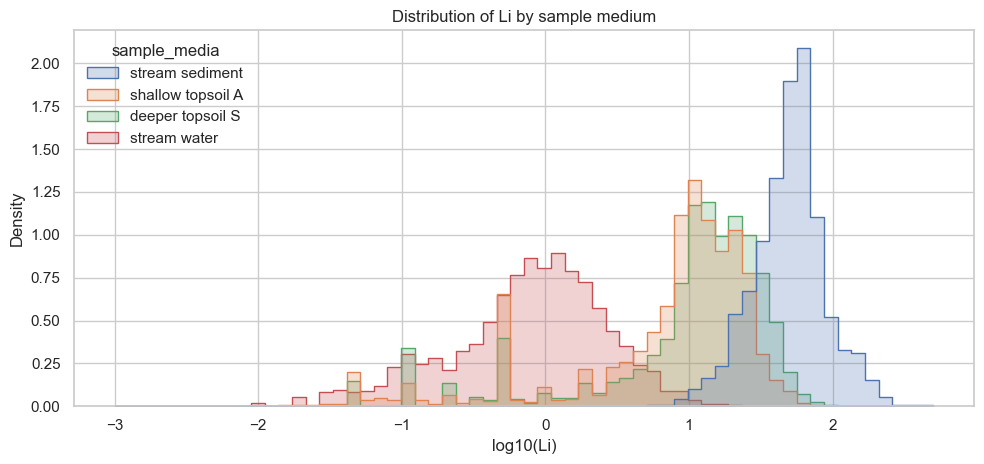

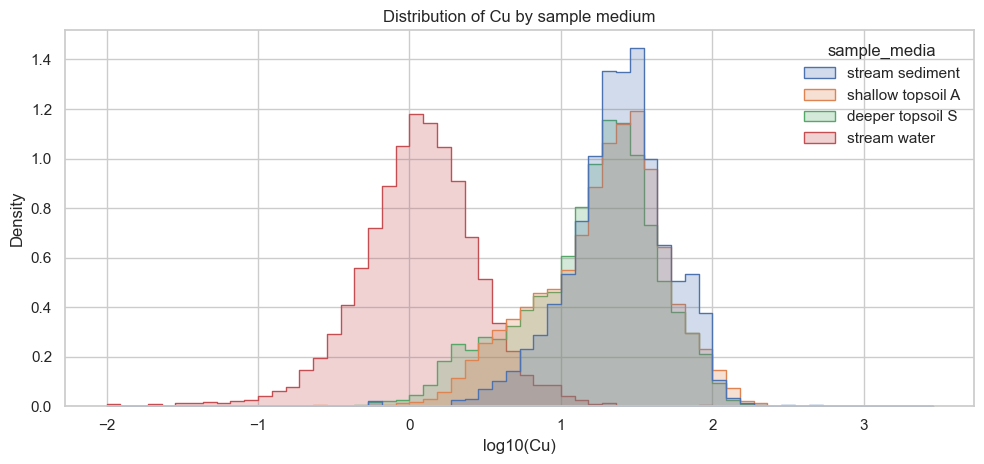

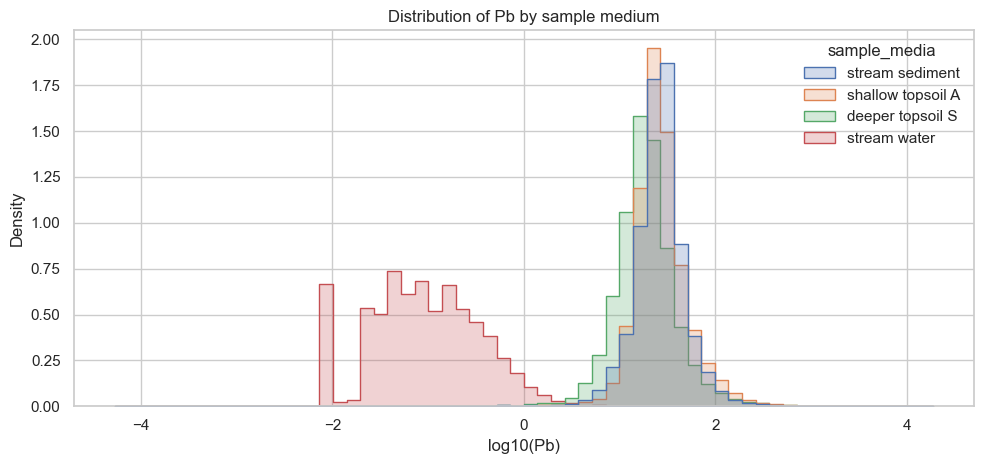

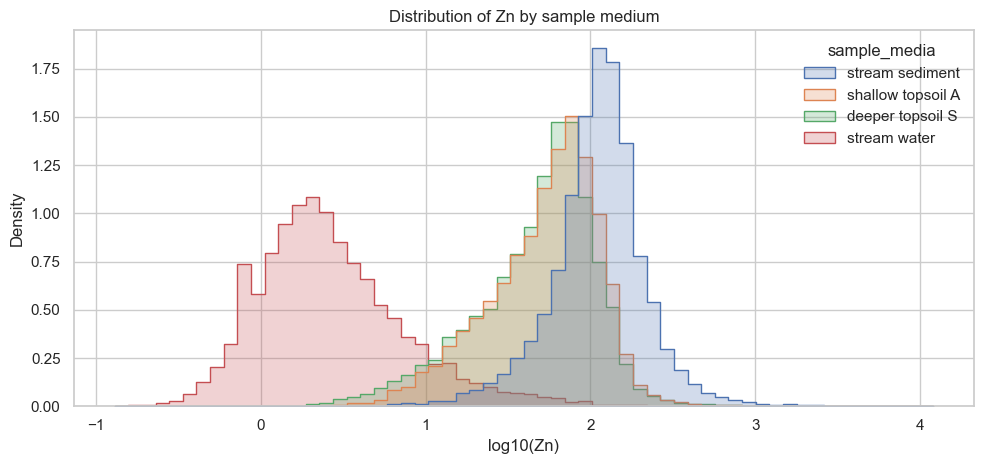

In [17]:
def plot_distribution(analyte, sample_media=None, log10=True):
    if not HAS_MPL:
        print("Install matplotlib to view this plot.")
        return
    data = long_geo[long_geo["analyte"].str.lower() == analyte.lower()].copy()
    if sample_media:
        data = data[data["sample_media"] == sample_media]
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["value"])
    if log10:
        data = data[data["value"] > 0].copy()
        data["plot_value"] = np.log10(data["value"])
        xlabel = f"log10({analyte})"
    else:
        data["plot_value"] = data["value"]
        xlabel = analyte
    if data.empty:
        print(f"No values available for {analyte}.")
        return
    fig, ax = plt.subplots(figsize=(10, 4.8))
    if HAS_SEABORN:
        sns.histplot(data=data, x="plot_value", hue="sample_media", bins=60, element="step", stat="density", common_norm=False, ax=ax)
    else:
        for media, g in data.groupby("sample_media"):
            ax.hist(g["plot_value"], bins=60, alpha=0.35, density=True, label=media)
        ax.legend()
    ax.set_title(f"Distribution of {analyte} by sample medium")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    plt.tight_layout()

for analyte in [a for a in ANALYTES_TO_PLOT if a in available_analytes][:4]:
    plot_distribution(analyte)

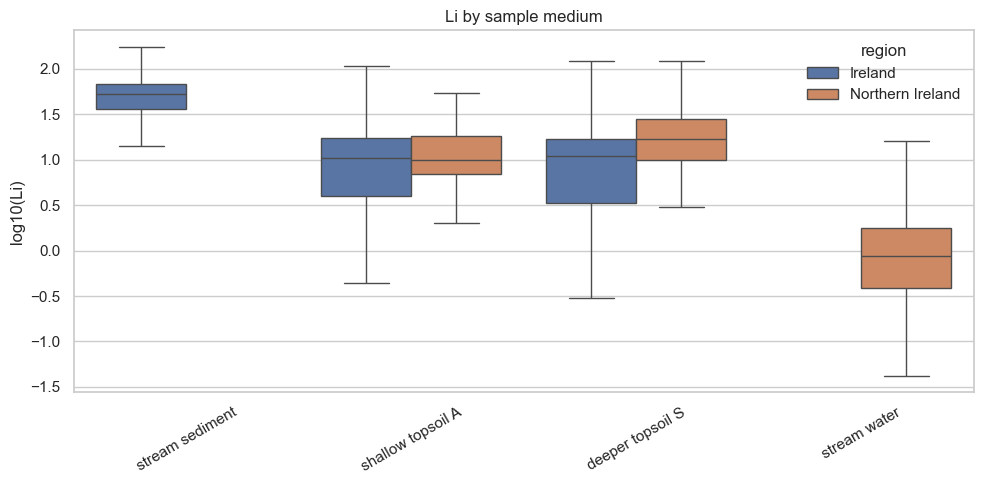

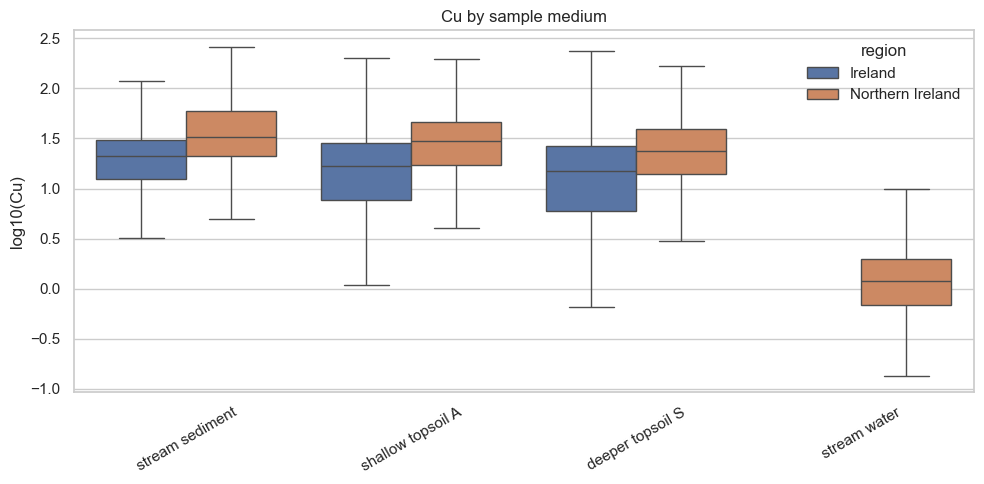

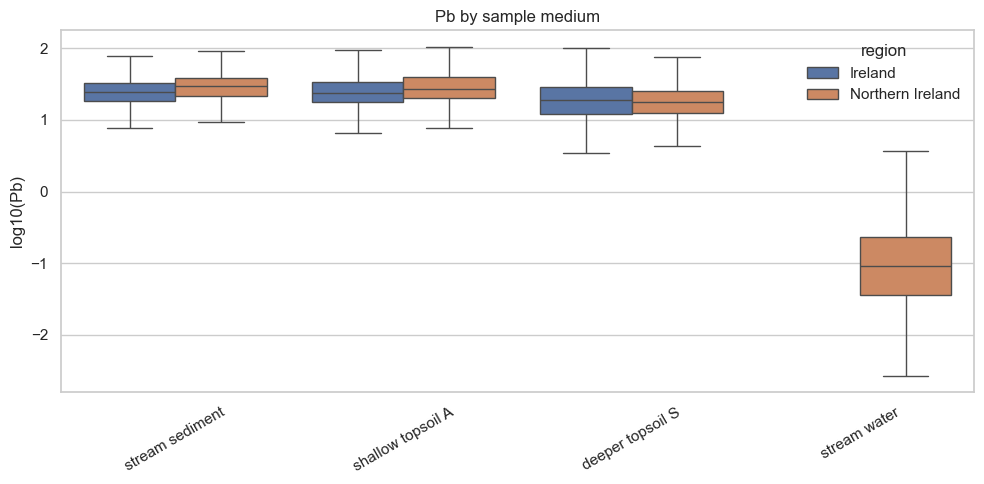

In [18]:
def plot_box_by_media(analyte, log10=True):
    if not HAS_MPL:
        print("Install matplotlib to view this plot.")
        return
    data = long_geo[long_geo["analyte"].str.lower() == analyte.lower()].copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["value"])
    if log10:
        data = data[data["value"] > 0].copy()
        data["plot_value"] = np.log10(data["value"])
        ylabel = f"log10({analyte})"
    else:
        data["plot_value"] = data["value"]
        ylabel = analyte
    if data.empty:
        print(f"No values available for {analyte}.")
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    if HAS_SEABORN:
        sns.boxplot(data=data, x="sample_media", y="plot_value", hue="region", showfliers=False, ax=ax)
    else:
        data.boxplot(column="plot_value", by="sample_media", ax=ax, grid=False)
    ax.set_title(f"{analyte} by sample medium")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()

for analyte in [a for a in ANALYTES_TO_PLOT if a in available_analytes][:3]:
    plot_box_by_media(analyte)

## 7. Correlation plots

Use these to find element associations. Keep the analysis within one sample medium where possible.

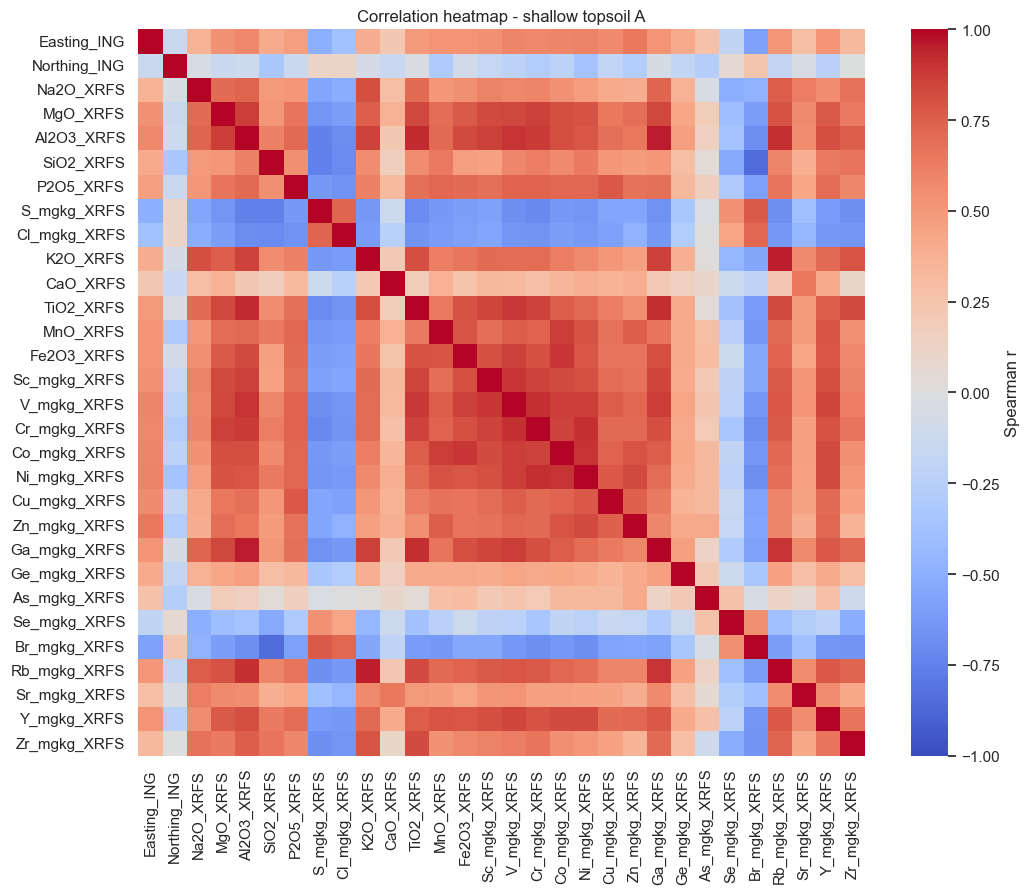

In [19]:
def correlation_heatmap(sample_media="shallow topsoil A", region=None, min_non_null=300, max_cols=30):
    if not HAS_MPL:
        print("Install matplotlib to view this plot.")
        return
    data = geo_num.copy()
    if sample_media:
        data = data[data["sample_media"] == sample_media]
    if region:
        data = data[data["region"] == region]
    cols = [c for c in numeric_cols if data[c].notna().sum() >= min_non_null]
    cols = cols[:max_cols]
    if len(cols) < 2:
        print("Not enough populated numeric columns for a heatmap. Lower min_non_null or choose another medium.")
        return
    corr = data[cols].corr(method="spearman", min_periods=min_non_null)
    fig, ax = plt.subplots(figsize=(11, 9))
    if HAS_SEABORN:
        sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax, square=True, cbar_kws={"label": "Spearman r"})
    else:
        im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
        ax.set_xticks(range(len(cols)))
        ax.set_yticks(range(len(cols)))
        ax.set_xticklabels(cols, rotation=90, fontsize=7)
        ax.set_yticklabels(cols, fontsize=7)
        fig.colorbar(im, ax=ax, label="Spearman r")
    ax.set_title(f"Correlation heatmap - {sample_media}" + (f" / {region}" if region else ""))
    plt.tight_layout()

correlation_heatmap("shallow topsoil A")

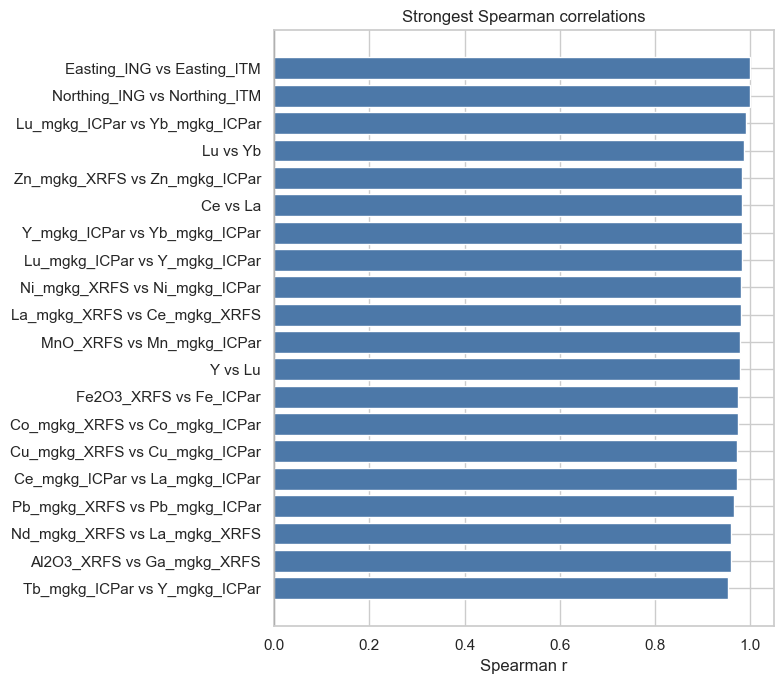

In [20]:
def strongest_correlations(sample_media="shallow topsoil A", region=None, min_non_null=300, top_n=20):
    data = geo_num.copy()
    if sample_media:
        data = data[data["sample_media"] == sample_media]
    if region:
        data = data[data["region"] == region]
    cols = [c for c in numeric_cols if data[c].notna().sum() >= min_non_null]
    if len(cols) < 2:
        return pd.DataFrame()
    corr = data[cols].corr(method="spearman", min_periods=min_non_null)
    pairs = []
    for i, c1 in enumerate(cols):
        for c2 in cols[i + 1:]:
            val = corr.loc[c1, c2]
            if pd.notna(val):
                pairs.append({"column_1": c1, "column_2": c2, "spearman_r": val, "abs_r": abs(val)})
    return pd.DataFrame(pairs).sort_values("abs_r", ascending=False).head(top_n)

pairs = strongest_correlations("shallow topsoil A")
if HAS_MPL and not pairs.empty:
    fig, ax = plt.subplots(figsize=(8, 7))
    labels = pairs["column_1"] + " vs " + pairs["column_2"]
    colors = np.where(pairs["spearman_r"] >= 0, "#4C78A8", "#E15759")
    ax.barh(labels, pairs["spearman_r"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Strongest Spearman correlations")
    ax.set_xlabel("Spearman r")
    ax.invert_yaxis()
    plt.tight_layout()
else:
    pairs

## 8. Optional PCA plot

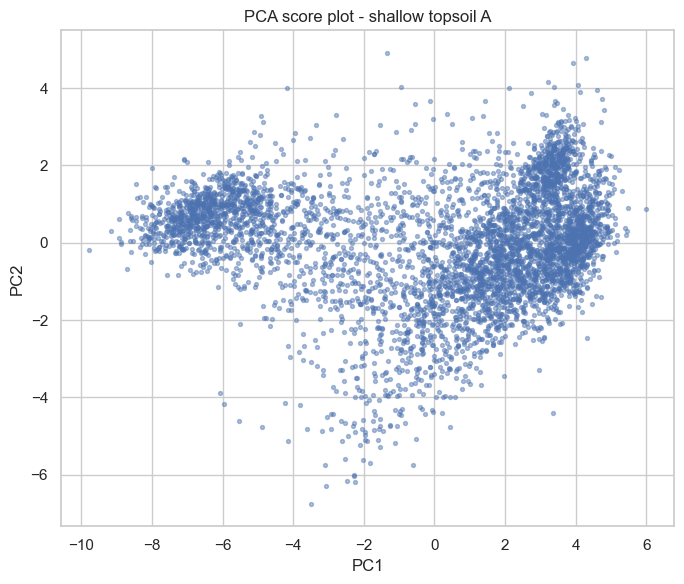

In [21]:
def pca_plot(sample_media="shallow topsoil A", region=None, min_non_null=500, max_cols=25, max_points=5000):
    if not HAS_MPL:
        print("Install matplotlib to view this plot.")
        return
    if not HAS_SKLEARN:
        print("Install scikit-learn to run PCA.")
        return
    data = geo_num.copy()
    if sample_media:
        data = data[data["sample_media"] == sample_media]
    if region:
        data = data[data["region"] == region]
    cols = [c for c in numeric_cols if data[c].notna().sum() >= min_non_null]
    cols = cols[:max_cols]
    X = data[cols].apply(pd.to_numeric, errors="coerce").dropna()
    if len(X) > max_points:
        X = X.sample(max_points, random_state=7)
    if X.shape[0] < 20 or X.shape[1] < 3:
        print("Not enough complete rows/columns for PCA.")
        return
    X_log = X.mask(X <= 0, np.nan).apply(np.log10).dropna()
    if X_log.shape[0] < 20:
        print("Not enough positive complete rows after log transform.")
        return
    X_scaled = StandardScaler().fit_transform(X_log)
    pca = PCA(n_components=2).fit_transform(X_scaled)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(pca[:, 0], pca[:, 1], s=8, alpha=0.45)
    ax.set_title(f"PCA score plot - {sample_media}" + (f" / {region}" if region else ""))
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()

pca_plot("shallow topsoil A")

## 9. Quick interpretation prompts

Use the plots above to answer these first-pass EDA questions:

- Are sample counts balanced across Ireland and Northern Ireland after `.xls` support is enabled?
- Do shallow and deeper topsoil show visibly different distributions for metals of interest?
- Are spatial patterns smooth, clustered, or dominated by isolated high values?
- Which analytes have enough coverage for modelling or mapping?
- Which highly correlated analyte pairs may represent shared lithology, analytical method effects, or contamination signatures?